# Set-up

## Load libraries

In [1]:
#Set directory
directory="C:/Users/atanoh/Documents/2026/CA125"
setwd(directory)
#Install and load libraires
invisible(source("./src/librairies.r"))
# Load functions
invisible(source("./src/functions.r"))


Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.2     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'reshape2'


L'objet suivant est masqué depuis 'package:tidyr':

    smiths



Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:dplyr':

    combine



Attachement du package : 'Matrix'


Les objets suivants sont masqués depuis '

## Load and clean dataset

In [2]:
#Load dataset
ca125 <- read.csv("./data/MAOV_ca125_all.csv", sep=";")
#Clean dataset
#check time between first surgery and first measure
Sys.setlocale("LC_TIME", "C")
ca125$delay_surg_trt<-(as.Date(toupper(ca125$dotrt_begin), format = "%d%b%Y")-as.Date(toupper(ca125$dosurg1), format = "%d%b%Y"))
#delete patients with delay <7
ca125 <- ca125%>%mutate(id=paste(trialid,"_",patid)) 
ca125<- ca125[!ca125$id %in% unique(ca125$id[ca125$delay_surg_trt < 7 & !is.na(ca125$delay_surg_trt)]),]

[1] "C"

In [3]:
# Clean first progression column
ca125 <- ca125 %>%
  mutate(
    dor = as.Date(toupper(dor), format = "%d%b%Y"),
    dofirst_prog = as.Date(toupper(dofirst_prog), format = "%d%b%Y"),
    dofirst_prog = if_else(
      is.na(dofirst_prog) & !is.na(dor),
      dor + pfs_time_m * 30.4375,
      dofirst_prog
    )
  )
ca125 <- ca125 %>%
  mutate(
    dotrt_begin = as.Date(toupper(dotrt_begin), format = "%d%b%Y"),
    donext_trt = as.Date(toupper(donext_trt), format = "%d%b%Y"),
    do_CA125 = as.Date(toupper(do_CA125), format = "%d%b%Y")
  )

In [4]:
#delete measures after progression 
ca125<-ca125 %>%
  filter( (trialid != "MRC-ICON7" & do_CA125 <= dofirst_prog) |
        (trialid == "MRC-ICON7" & time_ca125<=pfs_time_m * 30.4375))

In [5]:
#Create variables
ca125$trt_bin<- if_else(ca125$trt=="Standard regimen", 0,1)
ca125["os_time_d"]<-ca125$os_time_m*30.4375
ca125["pfs_time_d"]<-ca125$pfs_time_m*30.4375
ca125["os_statut"]<-ifelse(ca125$os_status=='Yes', 1, 0)
ca125["pfs_statut"]<-ifelse(ca125$PFS_status=='Yes', 1, 0)
#restrict data                             
colonnes<-c("trialid","patid","id",'trt','dor','CA125_mes','do_CA125','id_temp','dotrt_begin', "donext_trt",'dotrt_end',"time_ca125",'os_status','OS_time','PFS_status','PFS_time',"nb_mesures",
"ca125_base",'Visit','pfs_time_m',"pfs_time_d",'os_time_m',"os_time_d",'group','country','maov_group','dob','age','figo','figo4c',"trt_bin","os_statut","pfs_statut")
ca125_all_6 <- ca125[colonnes]%>%
  filter(time_ca125 <= 188) %>%
  group_by(id) %>%
  filter(n() > 1) %>%
  ungroup()
ca125_all_6["id_num"]<- as.numeric(as.factor(ca125_all_6$id))
ca125_all_6["trialid_num"]<- as.numeric(as.factor(ca125_all_6$trialid))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

**Summarise data**

In [6]:
ca125_all_6 %>%
  group_by(trialid) %>%
  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),
    
    # percentage deaths
    pct_death = mean(os_statut == 1, na.rm = TRUE) * 100,
    
    # percentage progression
    pct_progression = mean(pfs_statut == 1, na.rm = TRUE) * 100,
    
    # median OS time
    median_os_time_d = median(os_time_d, na.rm = TRUE),
    
    # median PFS time
    median_pfs_time_d = median(pfs_time_d, na.rm = TRUE),
    
    .groups = "drop"
  )

trialid,status,nb_measures,nb_patients,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Maintenance,648,194,17.12963,52.62346,329.9988,267.5000
CCTG-OV.16,No maintenance,5517,731,72.05003,84.73808,1443.9854,504.9886
DoCaCel,Maintenance,40,19,72.50000,77.50000,995.5000,374.5000
EORTC-55041,Maintenance,1982,772,43.89506,74.41978,1351.0000,424.0000
GINECO-2007,Intensification therapy,613,109,83.84992,92.49592,975.0000,445.0000
JGOG-3016,Intensification therapy,3240,552,46.57407,65.24691,1837.0000,841.0000
JGOG-3017,No maintenance,3497,608,18.84472,26.19388,1195.0000,1100.0000
MITO-7,Intensification therapy,1398,517,16.95279,51.64521,629.0000,490.0000
MRC-ICON7,Maintenance,10017,1471,46.14156,71.45852,1493.0000,576.0000


# Modeling CA125

## Evolution of CA-125

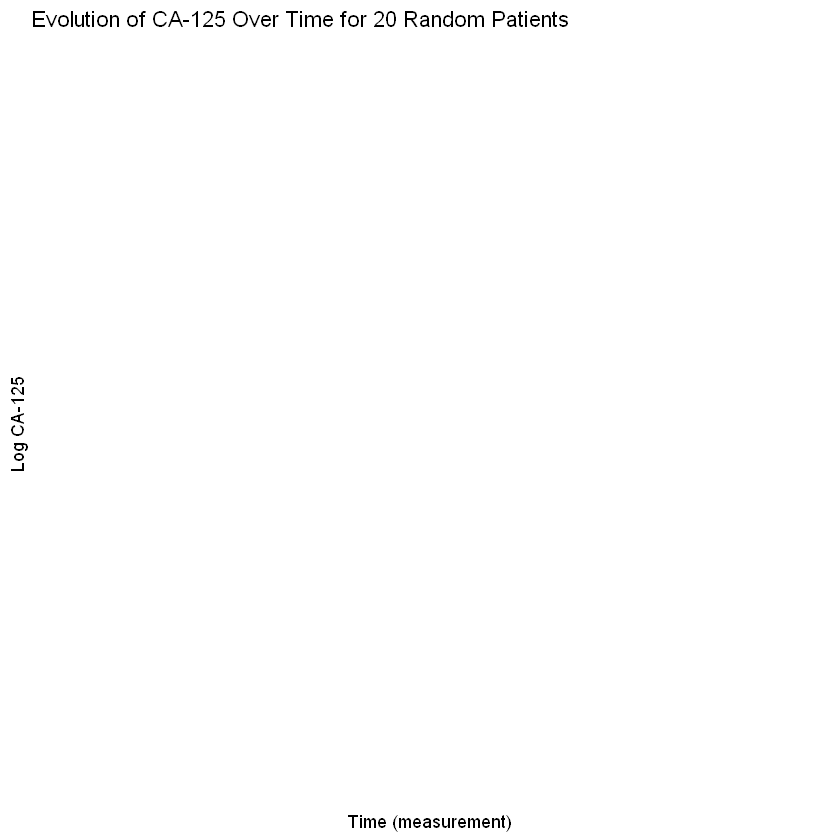

In [7]:
# set.seed(123)
# Select 20 random patients
selected_ids <- ca125_all_6 %>%
  distinct(id) %>%
  sample_n(20) %>%
  pull(id)
subset_data <- ca125_all_6[ca125_all_6$time_ca125<=90,] %>%
  filter(patid %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time for 20 Random Patients",
    x = "Time (measurement)", 
    y = "Log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")


In [8]:
# Compute trends per patient over 90 days of observation
df_trends_180 <- ca125_all_6%>%
  group_by(id) %>%
  summarise(trend_cat = trend(log_ca125, time_ca125), .groups = "drop")

# Join back to the original dataset
df_180 <- ca125_all_6 %>%
  left_join(df_trends_180, by = "id")
table(df_180$trend_cat)



decreasing increasing 
     43446       3810 

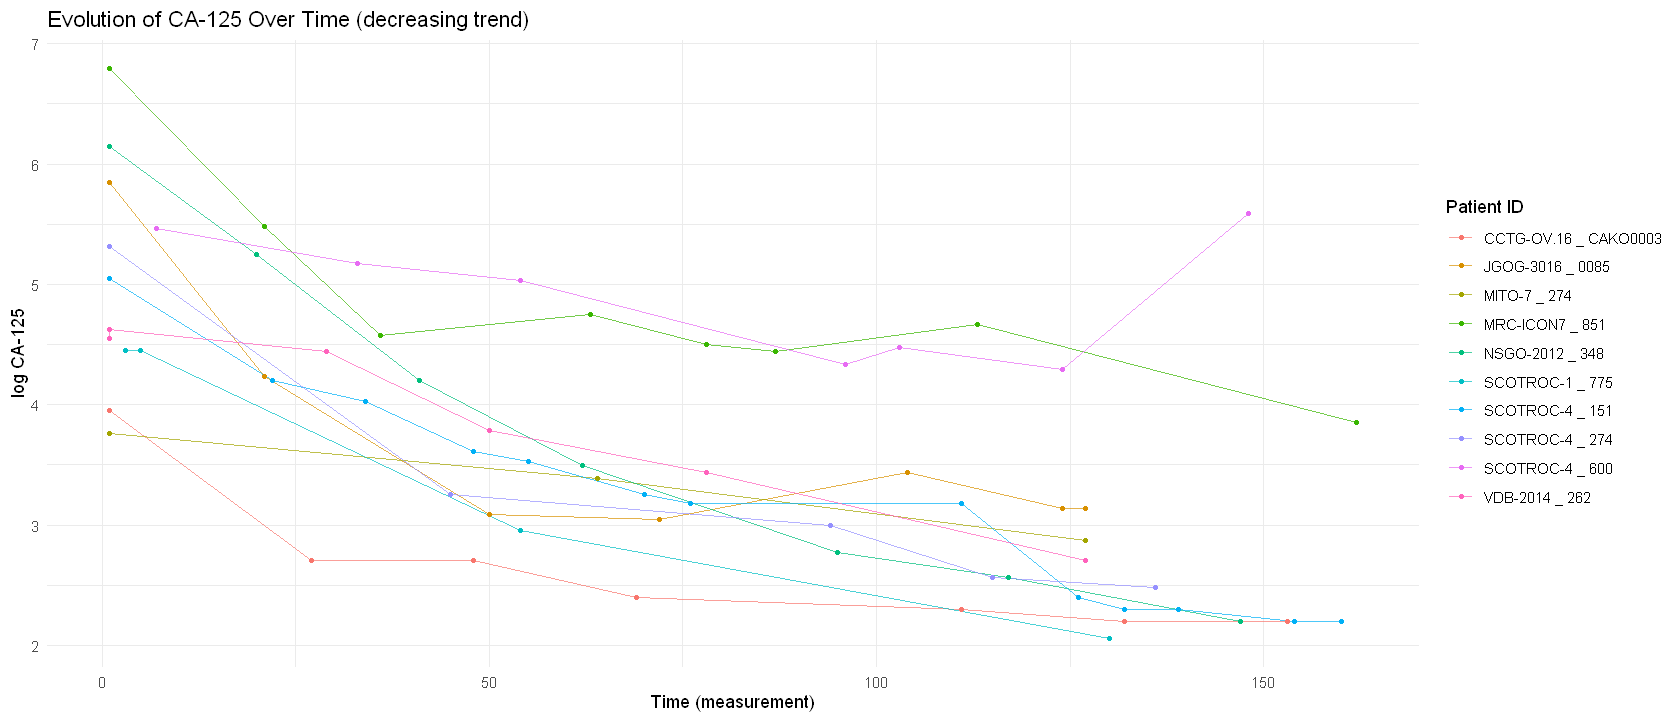

In [11]:
options(repr.plot.width = 14, repr.plot.height = 6)
selected_ids <- df_180[df_180$trend_cat=="decreasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (decreasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

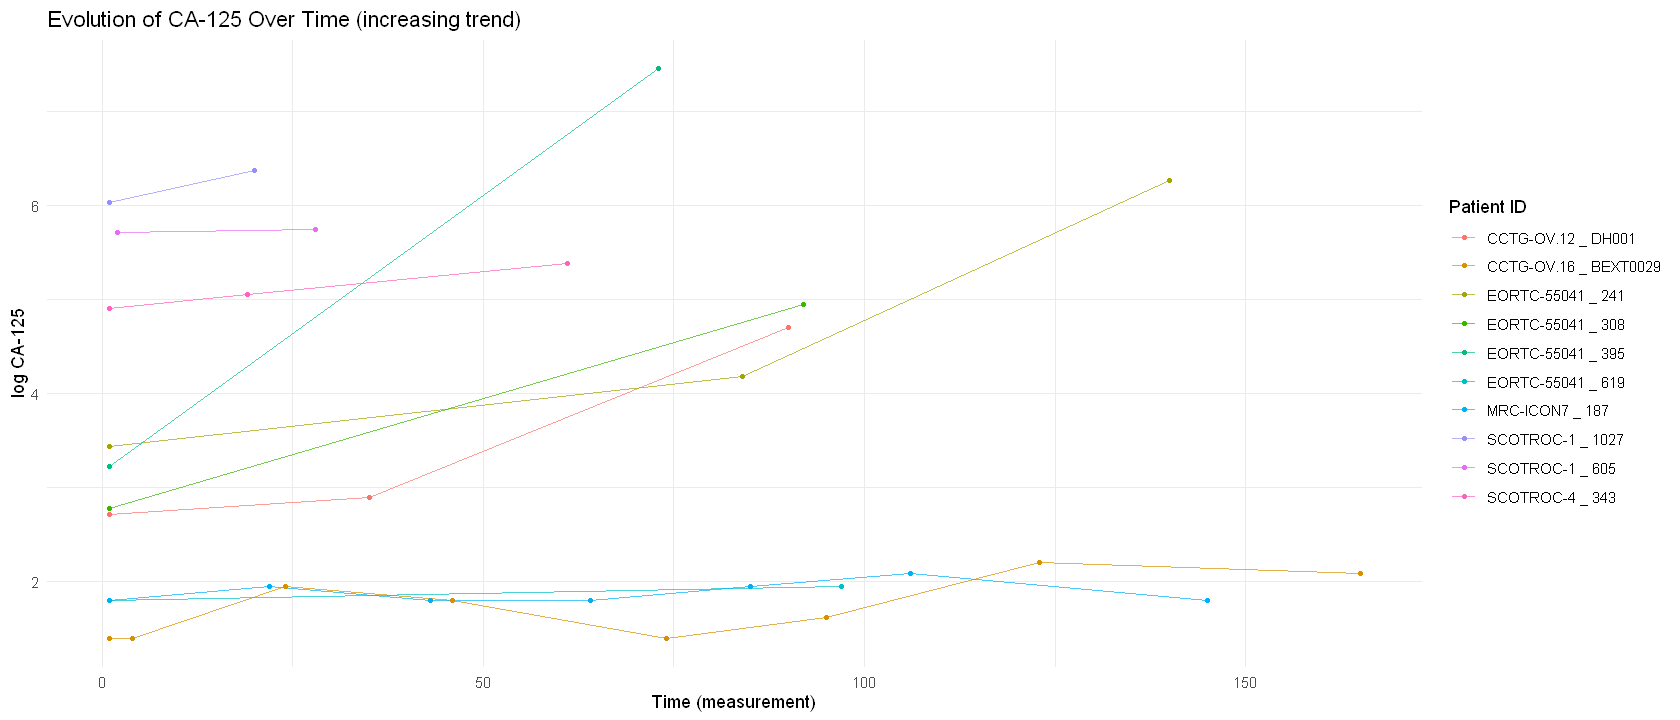

In [12]:
selected_ids <- df_180[df_180$trend_cat=="increasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (increasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

**Summarise CA-125 values**

In [13]:
ca125_all_6 %>%
  
  # keep repeated measures if you want ALL CA125 values
  group_by(trialid, trt_bin) %>%
  
  summarise(
    
    n_obs = n(),
    
    min_log_ca125 = min(log_ca125, na.rm = TRUE),
    
    q1_log_ca125 = quantile(log_ca125, 0.25, na.rm = TRUE),
    
    mean_log_ca125 = mean(log_ca125, na.rm = TRUE),
    
    q3_log_ca125 = quantile(log_ca125, 0.75, na.rm = TRUE),
    
    max_log_ca125 = max(log_ca125, na.rm = TRUE),
    
    .groups = "drop"
  ) %>%
  
  arrange(trialid, trt_bin)

trialid,trt_bin,n_obs,min_log_ca125,q1_log_ca125,mean_log_ca125,q3_log_ca125,max_log_ca125
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,0,322,-0.51082562,1.945910,2.806188,3.362069,8.857515
CCTG-OV.12,1,326,0.00000000,1.983753,2.815354,3.320429,8.259717
CCTG-OV.16,0,2806,-1.56064775,2.397895,3.546273,4.548863,9.375855
CCTG-OV.16,1,2711,-0.94160854,2.397895,3.714040,4.852030,9.399555
DoCaCel,0,24,2.19722458,2.397895,3.902400,5.048901,7.649693
DoCaCel,1,16,1.94591015,2.197225,3.476637,3.984057,6.952729
EORTC-55041,0,989,0.00000000,1.945910,2.775506,3.135494,9.562405
EORTC-55041,1,993,0.00000000,2.079442,2.785188,3.135494,8.245909
GINECO-2007,0,321,0.69314718,2.639057,3.899734,4.890349,9.433484


**Longitidunal model**

With splines :
- s trials
- $n_i$ patients in trial $i$, $n = \sum_{i=1}^{s} n_i$ the total number of patients
- $m_{ij}$ the number of measures for patient j in study i, $m_{i}=\sum_{j=1}^{n_i} m_{ij}$ the total number of observations in trial $i$, $N=\sum_{i=1}^{s} m_i=\sum_{i=1}^{s}\sum_{j=1}^{n_i} m_{ij}$ the total number of observations
- $y(t_{ijk})$ the $k^{th}$ value $k \in {1,...,m_{ij}}$ of biomarker CA-125 for patient $j$, $j \in {1,...,n_i}$, in study $i$, $i \in {1,...,s}$
- 
$$
T_{ij}=
\begin{cases} 
1 & \text{if patient $j$ in trial $i$ received the treatment} 
\\ 0 & \text{otherwise}
\end{cases}
$$

Mixed-effects model for varataion of $y$:
$
log[y(t_{ijk})]= f(t_{ijk}) +\epsilon_{ijk}
$, 
with:
- $ f(t)= (\theta_{1}+b_{1i}+b_{1ij}) + (\theta_{4}+b_{4ij})t+ \sum_{k=0}^1 (\theta_{k+2}+ b_{k+2,ij})B_{k+2}(t)+ (\theta_{5}+ b_{5,i})T_{ij}*t+ \sum_{k=0}^1 (\theta_{k+6}+ b_{k+6,i}) T_{ij}*B_{k+2}(t)$; $B_{k+2}(t) = d_{k} - d_2; d_k=\frac{(t-q_k(t))_{+}^3 - (t-q_3(t))_{+}^3}{q_k(t) - q_3(t)} \text{ , } k \in\ \{0,1\}$
- $x_+ = max (0, x)  $,
- $q_0(t), q_1(t), q_2(t) \text{ and } q_3(t)  \text{ are quantiles of t at 18\%, 22\%, 66\%, and 98\%} $
- $(b_{1i}, b_{5i},b_{6i},b_{7i})^\top \sim N(0, \phi)$, $\phi = \begin{pmatrix} \sigma_{1}^2 & \sigma_1\sigma_5 &\sigma_1\sigma_6 & \sigma_1\sigma_7\\ \sigma_1\sigma_5 & \sigma_{5}^2 & \sigma_5\sigma_6 & \sigma_5\sigma_7\\ \sigma_1\sigma_6 & \sigma_5\sigma_6 & \sigma_{6}^2& \sigma_6\sigma_7 \\ \sigma_1\sigma_7 & \sigma_5\sigma_7 & \sigma_6\sigma_7 & \sigma_{7}^2 \end{pmatrix}$  (random effect at study level)
- $ (b_{1ij},b_{4ij},b_{2ij}, b_{3ij})^t \sim N(0, D)$, $D = \begin{pmatrix} \sigma_{b1}^2 & \sigma_{b1b4} & \sigma_{b1b2} & \sigma_{b1b3} \\ \sigma_{b1b4} & \sigma_{b4}^2 &  \sigma_{b2b4} & \sigma_{b3b4} \\ \sigma_{b1b2} & \sigma_{b2b4} &\sigma_{b2}^2 & \sigma_{b2b3} \\ \sigma_{b1b3} & \sigma_{b3b4} & \sigma_{b2b3} & \sigma_{b3}^2 \end{pmatrix}$(random effects at patient-level)
- $\epsilon_{ijk} \sim N(0, \sigma^2_\epsilon I_N)$


**Conditional BLUP for patient-level random effects**:

- $\theta=(\theta_1 \text{  } \theta_4 \text{  } \theta_2 \text{  } \theta_3 \text{  } \theta_5 \text{  } \theta_6 \text{  } \theta_7)^T$

Matricial form: $ y= X\theta + Z_sb_s + Z_{n}b_{n} + \epsilon$, with :
$
y =
\begin{pmatrix}
y(t_{111}) \\
y(t_{112}) \\
\vdots \\
y(t_{11 m_{11}}) \\
y(t_{121}) \\
\vdots \\
y(t_{1 n_1 m_{1m=n_1}}) \\
\vdots \\
y(t_{s n_s m_{sn_s}})
\end{pmatrix}
\in \mathbb{R}^{N},
\qquad
$,
$
X =
\begin{pmatrix}
1 & t_{111} & B_2(t_{111}) & B_3(t_{111}) & T_{11}*t_{111} & T_{11}*B_2(t_{111}) & T_{11}*B_3(t_{111}) \\
1 & t_{112} & B_2(t_{112}) & B_3(t_{112}) & T_{11}*t_{112} & T_{11}*B_2(t_{112}) & T_{11}*B_3(t_{112}) \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
1 & t_{11 m_{11}} & B_2(t_{11 m_{11}}) & B_3(t_{11 m_{11}}) & T_{11}*t_{11 m_{11}} & T_{11}*B_2(t_{11 m_{11}}) & T_{11}*B_3(t_{11 m_{11}}) \\
1 & t_{121} & B_2(t_{121}) & B_3(t_{121}) & T_{12}*t_{121} & T_{12}*B_2(t_{121}) & T_{12}*B_3(t_{121})\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & t_{s n_s m_{sn_s}} & B_2(t_{s n_s m_{sn_s}}) & B_3(t_{s n_s m_{sn_s}}) & T_{sn_s}*t_{t_{s n_s m_{sn_s}}} & T_{sn_s}*B_2(t_{t_{s n_s m_{sn_s}}}) & T_{sn_s}*B_3(t_{t_{s n_s m_{sn_s}}})
\end{pmatrix}
\in \mathbb{R}^{N \times 7}
$
- $b_s \sim N(0, \Phi)$, $\Phi = \mathrm{diag}(\phi,...,\phi) \in \mathbb{R}^{6s \times 6s}$ (study-level random intercept)
$$
b_s =
\begin{pmatrix}
b_{11} & b_{51} &  b_{61}& b_{71} \\
b_{12} & b_{52} &  b_{62}& b_{72}  \\
\vdots & \vdots & \vdots & \vdots \\
b_{1s} & b_{5s} & b_{6s} &  b_{7s}
\end{pmatrix}
\in \mathbb{R}^{s \times 4}
$$
- $b_{n} \sim N(0, \Delta)$ (patient-level random intercept+slope), $
\Delta = \mathrm{diag}(D,...,D) \in \mathbb{R}^{5n \times 5n}
$

$$
b_{n} =
\begin{pmatrix}
b_{1,11} \\
b_{4,11} \\
b_{2,11} \\
b_{3,11} \\
b_{1,12} \\
b_{4,12} \\
b_{2,12} \\
b_{3,12} \\
\vdots \\
b_{1,s n_s} \\
b_{4,s n_s} \\
b_{2,s n_s}\\
b_{3,s n_s}
\end{pmatrix}
\in \mathbb{R}^{4n},
\qquad
$$

- $\epsilon \sim N(0, \sigma^2_{\epsilon}I_N)$

$\boxed{Var(y)=V=Z_s \Phi Z_s^T + Z_{n}\Delta Z_{n}^T + \sigma^2_{\epsilon}I_N}$\
with:
- $ Z_s =\begin{pmatrix}\mathbf{Z}_{s_1} & 0 & \cdots & 0 \\0 & \mathbf{Z}_{s_2} & \cdots & 0 \\\vdots & \vdots & \ddots & \vdots \\0 & 0 & \cdots & \mathbf{Z}_{s_s}\end{pmatrix} \in \mathbb{R}^{N \times 6s}$
. For trial $i$, $ Z_{s_i} =\begin{pmatrix}1 & T_{i1}*t_{i11} & T_{i1}*B_2(t_{i11}) & T_{i1}*B_3(t_{i11})\\1 & T_{i1}*t_{i12} & T_{i1}*B_2(t_{i12}) & T_{i1}*B_3(t_{i12}) \\\vdots & \vdots & \vdots\\1 & T_{in_i}*t_{in_im_i} & T_{in_i}*B_2(t_{in_im_i}) & T_{in_i}*B_3(t_{in_im_i}) \end{pmatrix}\in \mathbb{R}^{m_{i} \times 4}$

For patient $(i,j)$,:

$
Z_{ij}=\begin{pmatrix}1 & t_{ij1} & B_2(t_{ij1}) & B_3(t_{ij1})\\1 & t_{ij2}&  B_2(t_{ij2}) & B_3(t_{ij2})\\\vdots & \vdots & \vdots\\1 & t_{ijm_{ij}}& B_2(t_{ijm_{ij}}) & B_3(t_{ijm_{ij}})\end{pmatrix}\in \mathbb{R}^{m_{ij} \times 4}$, 
$
Z_{n}=\begin{pmatrix}Z_{11} & 0 & \cdots & 0\\0 & Z_{12} & \cdots & 0\\\vdots & \vdots & \ddots & \vdots\\0 & 0 & \cdots & Z_{s n_s}\end{pmatrix} \in \mathbb{R}^{N \times 4n}
$

$$
\widehat{b}_{n} = \Delta Z_{n}^\top V^{-1}(y-X\hat{\theta})
$$
$
\begin{pmatrix}
\hat b_{1ij} \\
\hat b_{4ij} \\
\hat b_{2ij}\\
\hat b_{3ij}
\end{pmatrix}
=[\Delta]_{ij}\sum_{k=1}^{m_{ij}}\begin{pmatrix}1\\ t_{ijk} \\B_2(t_{ijk}) \\B_3(t_{ijk})\end{pmatrix}\,\bigl[V^{-1}(y - X\hat\theta)\bigr]_{ijk}
$


**BLUP for Study-Level Random Effect**\
$$
\widehat{b}_{s} = \Phi Z_s^\top V^{-1} (y-X\hat{\theta}) 
$$
$
\begin{pmatrix}
\hat b_{1i} \\
\hat b_{5i} \\
\hat b_{6i}\\
\hat b_{7j}
\end{pmatrix}
=[\Phi]_{i} \sum_{j=1}^{n_i} \sum_{k=1}^{m_{ij}}\begin{pmatrix}1 \\T_{ij}*t_{ijk} \\T_{ij}*B_2(t_{ijk}) \\T_{ij}*B_3(t_{ijk})\end{pmatrix}\,\bigl[V^{-1}(y - X\hat\theta)\bigr]_{ijk}
$



**Fixed Effects Estimate**\
Stack all data across studies:
$$
\hat{\beta} = (\mathbf{X}^\top \mathbf{V}^{-1} \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{V}^{-1} \mathbf{y}
$$

In [14]:
internal_knots <- with(ca125_all_6,quantile(time_ca125, probs = c(0.22, 0.66)))
boundary_knots <- with(ca125_all_6,quantile(time_ca125, probs = c(0.18, 0.98)))
ncs_trt_all <- lmer(
  log(CA125_mes) ~ ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)+ trt_bin:ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)+
    (ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots) | id)+ (trt_bin:ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)|trialid),
  data = ca125_all_6,
  control = lmerControl(
    optimizer = "bobyqa",
    optCtrl = list(maxfun = 2e5)
  )
)
attr(terms(ncs_trt_all), "predvars")
summary(ncs_trt_all)

list(log(CA125_mes), ns(time_ca125, knots = c(`22%` = 21, `66%` = 92
), Boundary.knots = c(`18%` = 8, `98%` = 180), intercept = FALSE), 
    trt_bin)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
log(CA125_mes) ~ ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) +  
    trt_bin:ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) +  
    (ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) |  
        id) + (trt_bin:ns(time_ca125, knots = internal_knots,  
    Boundary.knots = boundary_knots) | trialid)
   Data: ca125_all_6
Control: lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e+05))

REML criterion at convergence: 93236.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-15.0579  -0.3061  -0.0159   0.2809   9.8233 

Random effects:
 Groups  
 id      
         
         
         
 trialid 
         
         
         
 Residual
 Name                                                                            
 (Intercept)                                                                     
 

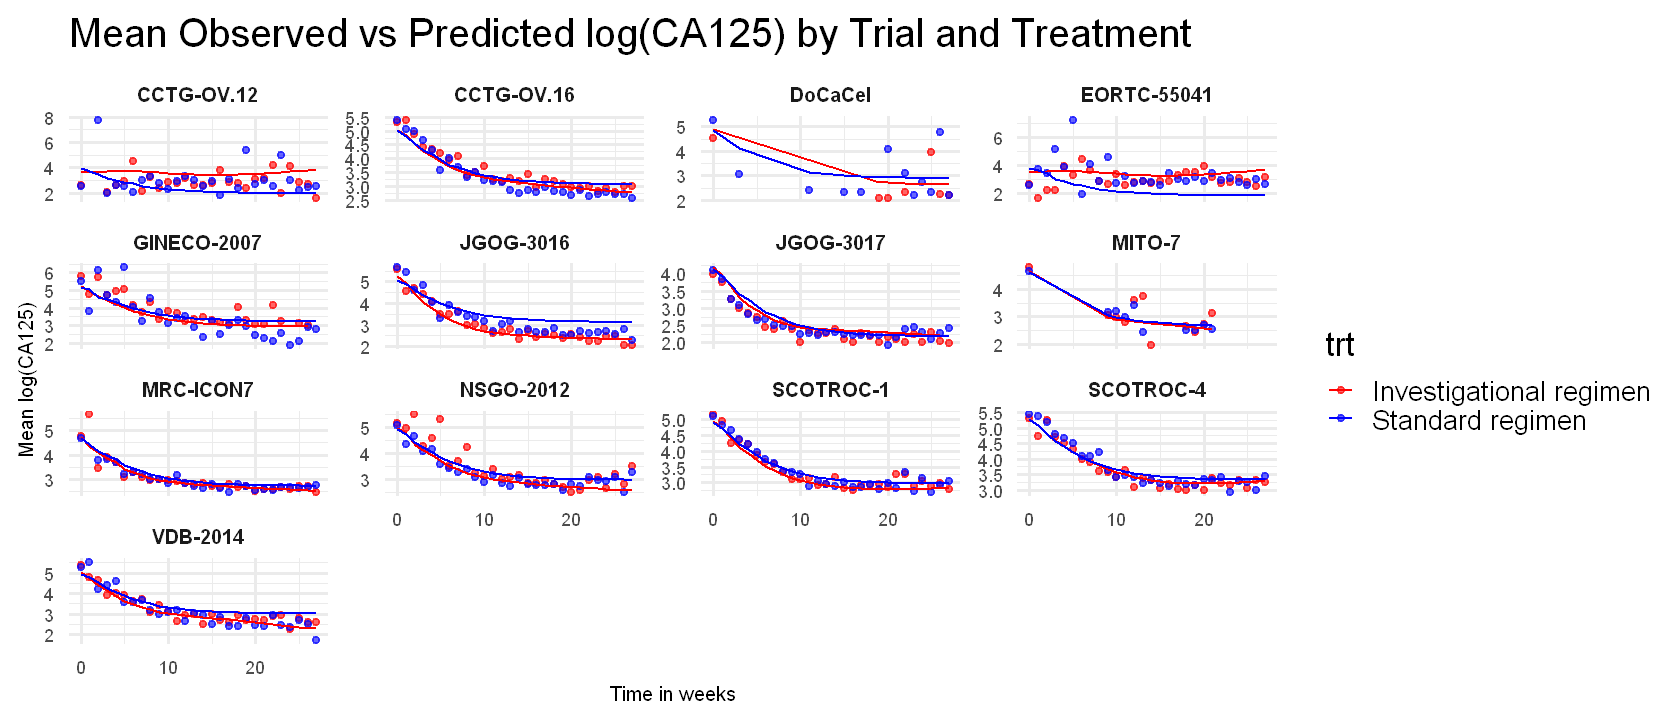

In [15]:
# Comparison between real trajectories and predicited ones
# => bij=0
ca125_all_6 %>% mutate(week=round(time_ca125/7))%>%mutate(pred_all_13_nullbij= predict(
  ncs_trt_all,
  newdata = ca125_all_6,
  re.form = ~(trt_bin:ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) | trialid)
))%>%
  group_by(trt, trialid, week) %>%
  summarise(
    mean_log_ca125 = mean(log(CA125_mes), na.rm = TRUE),
    mean_pred      = mean(pred_all_13_nullbij, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  ggplot(aes(x = week, color = trt, group = trt)) +
  geom_point(aes(y = mean_log_ca125),
             alpha = 0.6, size = 1.6) +
  geom_line(aes(y = mean_pred),
            linewidth = 0.8) +
  facet_wrap(~ trialid, scales = "free_y") +
  scale_color_manual(values = c(
    "Standard regimen" = "blue",
    "Investigational regimen" = "red"
  )) +
  labs(
    title = "Mean Observed vs Predicted log(CA125) by Trial and Treatment",
    x = "Time in weeks",
    y = "Mean log(CA125)"
  ) +
  theme_minimal(base_size=20) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
 

# Survival analysis

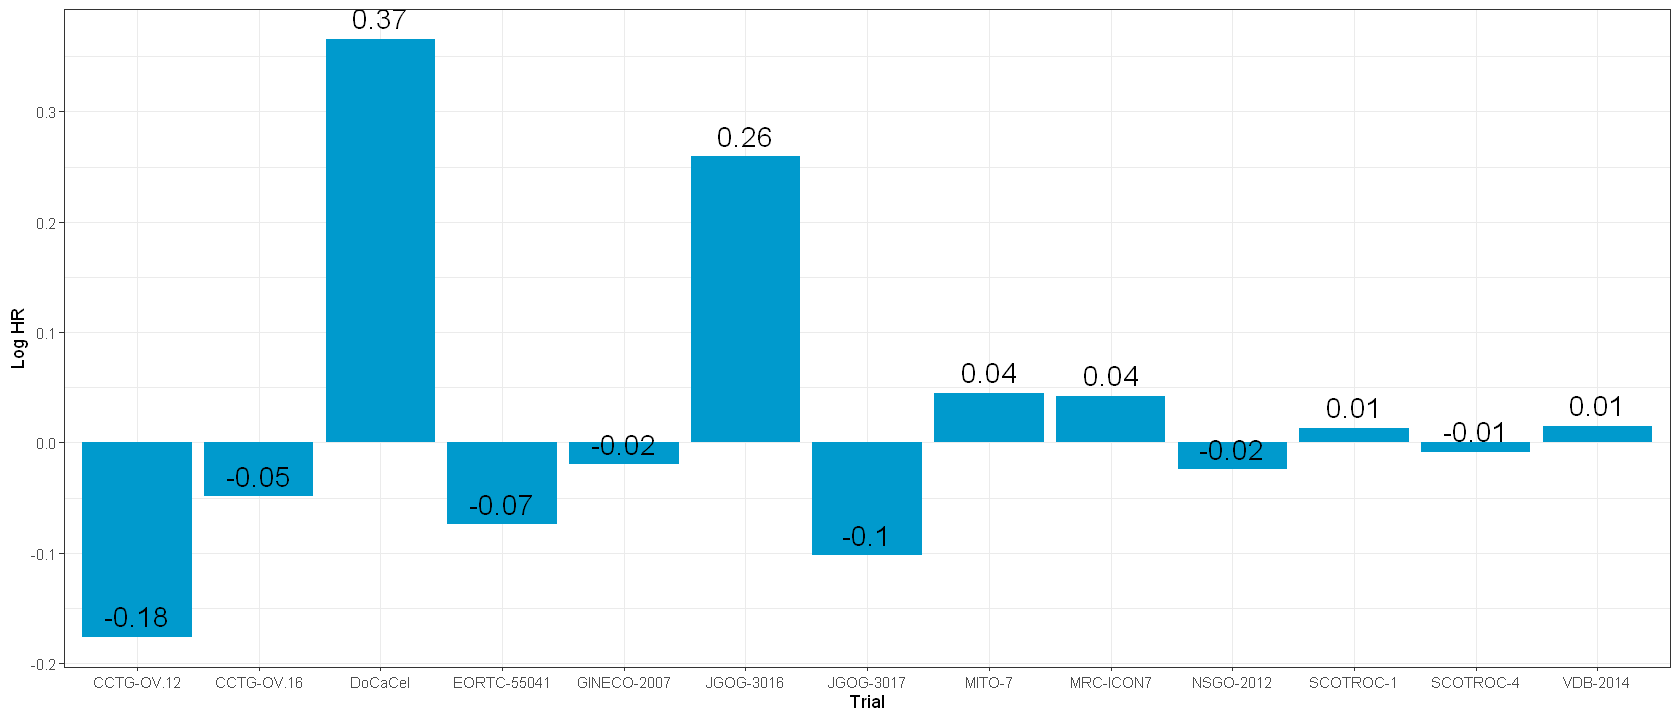

In [18]:
#Model
cox_results <- ca125_all_6%>%
  group_by(trialid) %>%
  group_modify(~ {
    if(nrow(.x) == 0 || length(unique(.x$trt)) < 2) return(tibble())
    
    fit <- coxph(Surv(pfs_time_m*30.4375, pfs_statut) ~ trt, data = .x)
    tibble(
      logHR = coef(fit)[1],
      n_patients = nrow(.x)
    )
  }) %>%
  ungroup()
# Plot
cox_results %>%
  ggplot(aes(x = trialid,y = logHR))+
  geom_col(fill = "deepskyblue3") +
  geom_text(aes(label = round(logHR, 2)),
            vjust = -0.5,
            size = 6)+ 
  theme_bw() + 
  labs(x = "Trial",
       y = "Log HR") 

# Joint modeling

## Model

**Longitudinal model**
$
Y_i(t) = (\beta_0 +b_{0i})+ \sum_{k=1}^{3} (\beta_k+b_{ki}) \, ns_k(t)+ \sum_{k=1}^{3} \gamma_k \, ns_k(t)*T_i+ \varepsilon_i(t)
$

$
b_i \sim \mathcal{N}(0, D), \quad \varepsilon_i(t) \sim \mathcal{N}(0, \sigma^2)
$\
**Survival model**
$
h_i(t) = h_0(t)\exp(\alpha \, T_i)
$

$
h_0(t) = \sum_{m=1}^{M} \lambda_m B_m(t)
$

**Joint association structure**

$
h_i(t \mid b_i) = h_0(t)\exp(\alpha \, T_i + \eta^\top b_i)
$\
**Full likelihood**

$
L = \prod_{i=1}^N 
\int 
f(Y_i \mid b_i)\,
f(T_i, \delta_i \mid b_i)\,
f(b_i)\, db_i
$

In [ ]:
#Model pfs
# jointed_lcmm_pfs<-Jointlcmm(
#   fixed=log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + ns2 + ns3),
#   random=~ ns1 + ns2 + ns3,
#   subject="id_num",
#   ng = 1,
#   survival=Surv(pfs_time_d, pfs_statut) ~ trt_bin,
#   hazard = "splines",
#   data=ca125_all_6)
# saveRDS(jointed_lcmm_pfs, file = "jointed_lcmm_pfs.rds")

In [19]:
jointed_lcmm_pfs<-readRDS("./results/models/jointed_lcmm_pfs.rds")

In [20]:
summary(jointed_lcmm_pfs)

Joint latent class model for quantitative outcome and competing risks 
     fitted by maximum likelihood method 
 
Jointlcmm(fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + 
    ns2 + ns3), random = ~ns1 + ns2 + ns3, subject = "id_num", 
    ng = 1, survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin, 
    hazard = "splines", data = ca125_all_6)
 
Statistical Model: 
     Dataset: ca125_all_6 
     Number of subjects: 8140 
     Number of observations: 47463 
     Number of latent classes: 1 
     Number of parameters: 26  
     Event 1: 
        Number of events: 5544
        M-splines constant baseline risk function with nodes 
        0 289 508 980 5310.001  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  78 
     Convergence criteria: parameters= 1.3e-09 
                         : likelihood= 7.9e-06 
                         : second derivatives= 4.8e-06 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -90969.66  
     AIC: 1

* CI (Conditional independence) assuptiom (p-value=0) => longitudinal process and progression-time are not independent given random effects => CA125 itself carries additional information about progression, apart from patient-specific characteristics
* No treatment effect on progression-time
* Splines coeffs are significant => The risk of progression and evolution of CA125 vary nonlinearly over time
* High variances => patient-level heterogeneity in baseline CA125 and trajectory shape

## Predictions

dynpred: “Given what I have observed as CA125 values for this patient up to time t, what is their survival probability going forward?”

# 🔹 Step-by-step mathematical idea behind dynamic prediction

## 1. Joint model specification

We consider a joint model with two linked components:

### Longitudinal model
$
Y_i(t) = X_i(t)\beta + Z_i(t) u_i + \epsilon_i(t)
$

- $ Y_i(t)$:  log CA125
- $ u_i $: subject-specific random effects
- $\epsilon_i(t)$: measurement error

### Survival model
$
\lambda_i(t \mid u_i) = \lambda_0(t)\exp\big(\gamma X_i + \alpha f(u_i, t)\big)
$

- $ \lambda_0(t)$: baseline hazard
- The hazard depends on the subject’s latent trajectory via $ u_i$

## 2. Unknown random effects

The random effects $ u_i $ are not observed.  
Instead, we estimate their posterior distribution using the observed longitudinal data up to time $ s $:

$
p(u_i \mid \text{data up to time } s)
$


## 3. Conditional survival given $ u_i $

If $ u_i $ were known, the survival function is:

$
S_i(t \mid u_i) = \exp\left(-\int_0^t \lambda_i(u \mid u_i)\, du \right)
$

The conditional probability of experiencing the event in the interval \([s, s+t]\) is:

$
P(T_i \le s+t \mid T_i > s, u_i)
= 1 - \frac{S_i(s+t \mid u_i)}{S_i(s \mid u_i)}
$


## 4. Marginal prediction (integrating over $ u_i $)

Since $ u_i $ is unknown, we integrate over its posterior distribution:

$
P(T_i \le s+t \mid \text{data}) =
\int \left[
1 - \frac{S_i(s+t \mid u_i)}{S_i(s \mid u_i)}
\right]
p(u_i \mid \text{data up to } s)\, du_i
$


## 5. Monte Carlo approximation

This integral is approximated numerically:

1. Draw samples:
$
u_i^{(1)}, \dots, u_i^{(M)} \sim p(u_i \mid \text{data})
$

2. Compute for each draw:
$
p^{(m)} = 1 - \frac{S_i(s+t \mid u_i^{(m)})}{S_i(s \mid u_i^{(m)})}
$

3. Summarize:
- Median → predicted probability
- 2.5% and 97.5% → confidence interval


## 6. Interpretation

This gives a **dynamic prediction**:

$
P(T_i \le s+t \mid T_i > s,\ \text{history up to } s)
$

That is, the probability that subject $ i $ experiences the event in the next $ t $ time units, given:
- they are event-free at time $ s $
- their observed biomarker trajectory up to time $ s $

In [ ]:
# #Predictions
# pred <- dynpred(
#   model = jointed_lcmm_pfs,
#   newdata = ca125_all_6,
#   event = 1,
#   landmark = c(180),
#   horizon = c(550,915,1645),
#   var.time = "time_ca125",
#   draws = TRUE,
#   ndraws = 100
# )
# dynpreds<-saveRDS(pred, file = "pred_dynpred.rds")

In [21]:
dynpreds<-readRDS("./results/models/pred_dynpred.rds")

In [29]:
# Evaluation of prediction of progression at 2, 3 and 5 years
# horizons:
# 550  = ~2 years
# 915  = ~3 years
# 1645 = ~5 years

# function for manual AUC
auc_manual <- function(labels, scores) {
  roc_obj <- pROC::roc(labels, scores, quiet = TRUE)
  as.numeric(pROC::auc(roc_obj))
}

# evaluation for each horizon
eval_df <- map_dfr(
  c(550, 915, 1645),
  function(h) {
    
    # convert horizon to years for observed event definition
    years <- case_when(
      h == 550  ~ 2,
      h == 915  ~ 3,
      h == 1645 ~ 5
    )
    
    obs <- dynpreds[[1]] %>%
      filter(horizon == h) %>%
      select(id_num, pred) %>%
      left_join(
        ca125_all_6 %>%
          select(id_num, pfs_time_d, pfs_statut) %>%
          distinct(),
        by = "id_num"
      ) %>%
      mutate(
        event = ifelse(pfs_time_d <= years * 365 & pfs_statut == 1, 1, 0),
        pred_class = as.numeric(pred >= 0.5)
      )
    
    obs %>%
      summarise(
        years = years,
        
        accuracy =
          mean(pred_class == event, na.rm = TRUE),
        
        sensitivity =
          sum(pred_class == 1 & event == 1, na.rm = TRUE) /
          sum(event == 1, na.rm = TRUE),
        
        specificity =
          sum(pred_class == 0 & event == 0, na.rm = TRUE) /
          sum(event == 0, na.rm = TRUE),
        
        auc =
          auc_manual(event, pred),
        
        n_events =
          sum(event, na.rm = TRUE),
        
        n_patients =
          n()
      )
  }
)

eval_df

years,accuracy,sensitivity,specificity,auc,n_events,n_patients
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2,0.4390554,0.0000000,0.9172821,0.5070629,4548,8140
3,0.6268382,0.8774743,0.0000000,0.5068975,5052,8140
5,0.6638857,0.8798726,0.0000000,0.5108831,5336,8140


## Link between risk ratio and CA125

**One joint model per trial**

In [ ]:
results_list <- list()
ca125_all_6<-ca125_all_6 %>%arrange(id_num)
trial_list <- split(ca125_all_6, ca125_all_6$trialid)
for (trial_name in names(trial_list)) {
  
  cat("Fitting trial:", trial_name, "\n")
  
  df <- trial_list[[trial_name]]
  internal_knots <- quantile(df$time_ca125, probs = c(0.22,0.66))
  boundary_knots <- quantile(df$time_ca125, probs = c(0.18,0.98))
  ns_basis <- ns( df$time_ca125, knots = internal_knots, Boundary.knots = boundary_knots ) 
  # Add to dataset 
  colnames(ns_basis) <- paste0("ns", 1:ncol(ns_basis)) 
  df <- cbind(df, ns_basis)
  df$trt_ns1 <- df$trt_bin * df$ns1
  df$trt_ns2 <- df$trt_bin * df$ns2
  df$trt_ns3 <- df$trt_bin * df$ns3
  
  res <- tryCatch({
    
    # -------------------------
    # 1. Joint model
    # -------------------------
    model <- Jointlcmm(
      fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + ns2 + ns3),
      random = ~ ns1 + ns2 + ns3,
      subject = "id_num",
      ng = 1,
      survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin,
      hazard = "splines",
      data = df
    )
    
    # -------------------------
    # 2. Dynamic predictions
    # -------------------------
    newdata_trt1 <- df; newdata_trt1$trt_bin <- 1
    newdata_trt0 <- df; newdata_trt0$trt_bin <- 0
    
    dyn1 <- dynpred(model, newdata_trt1,
                    landmark = 180, horizon = 550,
                    var.time = "time_ca125")
    
    dyn0 <- dynpred(model, newdata_trt0,
                    landmark = 180, horizon = 550,
                    var.time = "time_ca125")
    
    rr_df <- dyn1$pred %>%
      select(id_num, pred) %>%
      rename(pred1 = pred) %>%
      left_join(
        dyn0$pred %>%
          select(id_num, pred) %>%
          rename(pred0 = pred),
        by = "id_num"
      ) %>%
      mutate(
        rr_joint = pred1 / pred0,
        log_rr_joint = log(rr_joint)
      )
    
    # -------------------------
    # 3. Build pseudo-time from risk
    # -------------------------
    rr_df <- rr_df %>%
      mutate(
        # transform risk -> pseudo survival time
        time_pred1 = -log(1 - pred1),
        time_pred0 = -log(1 - pred0)
      )
    
    # -------------------------
    # 4. Cox on predicted times
    # -------------------------
    # stack data
    cox_data <- bind_rows(
      rr_df %>% mutate(time = time_pred1, trt = 1),
      rr_df %>% mutate(time = time_pred0, trt = 0)
    )
    
    # fake event
    cox_data$event <- df[!duplicated(df$id),]$pfs_statut
    
    cox_fit <- coxph(Surv(time, event) ~ trt, data = cox_data)
    
    log_rr_cox <- coef(cox_fit)[["trt"]]
    
    # -------------------------
    # 5. CA125 prediction
    # -------------------------
    log_ca125_pred <- predictY(
      model,
      newdata = df,
      var.time = "time_ca125"
    )$pred
    
    ca125_patient <- data.frame(
      id_num = df$id_num,
      log_ca125_pred = as.vector(log_ca125_pred)
    ) %>%
      group_by(id_num) %>%
      summarise(
        log_ca125_pred = mean(log_ca125_pred, na.rm = TRUE),
        .groups = "drop"
      )
    
    rr_df <- rr_df %>%
      left_join(ca125_patient, by = "id_num")
    
    # -------------------------
    # 6. Trial summary
    # -------------------------
    trial_summary <- rr_df %>%
      summarise(
        mean_log_rr_joint = mean(log_rr_joint, na.rm = TRUE),
        mean_log_ca125 = mean(log_ca125_pred, na.rm = TRUE),
        n_events = sum(df$pfs_statut),
        .groups = "drop"
      ) %>%
      mutate(
        trialid = trial_name,
        log_rr_cox = log_rr_cox,
        diff_rr = log_rr_cox - mean_log_rr_joint
      )
    
    trial_summary
    
  }, error = function(e) {
    cat("❌ Failed:", trial_name, "\n")
    print(e$message)
    NULL
  })
  
  results_list[[trial_name]] <- res
}

trial_summary_all <- bind_rows(results_list)

Fitting trial: CCTG-OV.12 


Warning message in Surv(time = c(783.99999375, 783.99999375, 783.99999375, 376.000525, :
"type= 'mstate' is deprecated, use a factor variable as status"


In [ ]:

# =========================
# Plot
# =========================
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(trial_summary_all,
       aes(x = mean_log_ca125,
           y = mean_log_rr_joint,
           size = n_events)) +
  geom_point(color = "blue", alpha = 0.7) +
  geom_text(aes(label = trialid), vjust = -1, size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  scale_size(range = c(3, 10)) +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    x = "Mean predicted log(CA-125)",
    y = "Mean log relative risk (PFS)",
    title = "Trial-level association between CA125 and progression risk"
  ) +
  ylim(-1, 1)

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 8)
#compare both RRs
ggplot(trial_summary_all, aes(x = trialid)) +
  geom_point( aes(y = log_rr_cox,size = n_events), color = "blue", alpha = 0.7) +
  geom_point( aes(y = mean_log_rr_joint,size = n_events), color = "red", alpha = 0.7) +
  
  geom_text(aes(label = trialid, y = log_rr_cox), vjust = -1, size = 3) +
  
  theme_minimal() +
  theme(legend.position = "none") +
  
  labs(
    x = "Log RR (Joint model)",
    y = "Log RR (Cox on predicted time)",
    title = "Comparison of treatment effect estimates"
  )